# Elbow rep checker: model training

Trains the autoencoder that decides whether one elbow-flexion rep looks like a healthy rep, and
saves everything the live coach (`elbow_coach.py`) needs.

**How it works.** The autoencoder only ever sees *correct* reps. It learns to squeeze a rep's elbow-angle
curve into 4 numbers and rebuild it. A correct rep rebuilds well; a rep that is too shallow, not straight at the
end, too fast, etc. rebuilds badly. The rebuild error is the score, and a threshold turns it into a warning.

**Data (all elbow angle in degrees, one rep = 100 time steps, plus how long the rep took)**

| Dataset | Used for | Reps |
|---|---|---|
| ULTra-MoCap, elbow flexion | training (healthy, mocap) | cut from continuous recordings |
| IRDS gestures 0 and 1, healthy subjects (1xx, 3xx) | threshold reference + optional training | Kinect |
| IRDS gestures 0 and 1, patients (2xx) | choosing the model, tuning and testing the threshold | Kinect, labelled correct / incorrect |

UI-PRMD is not used: its shoulder exercises keep the elbow nearly flat, which made the model worse (`three_results.txt`).

**Rules that keep the numbers honest**

- Nobody appears in two parts (train / early stop / tuning / test are split by person).
- The model mix and input version are chosen on the 7 *tuning* patients only. The 7 *test* patients are scored once, at the end.

**Before running**
- *On your computer:* run it from the project folder. It builds `ultra_elbow.npz` and `irds_features.npz` itself from
  `All_subjects_data.h5` and `SkeletonData` if they are missing. Needs numpy, torch, scikit-learn, matplotlib, h5py, scipy.
- *In Google Colab:* your project folder is not there, and the raw data is far too large to upload. Upload only these
  small files (the data cell offers an upload button): `ultra_elbow.npz`, `irds_features.npz`. To also run the final
  check in section 7, upload `elbow_coach.py`, `arm_features.py`, `train_autoencoder.py` (otherwise that check is skipped).

In [1]:
import os
import subprocess
import sys
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
from torch import nn

# ---- settings ---------------------------------------------------------------------------
SEEDS = [0, 1, 2]
ULTRA_TRAIN_SUBJECTS, ULTRA_STOP_SUBJECTS = list(range(1, 12)), [12, 13]   # ULTra-MoCap people
IRDS_STOP_SUBJECTS = [107, 307]                                            # healthy IRDS people used for early stopping
TUNE_PATIENTS = [204, 206, 207, 209, 210, 211, 214]                        # choose model + balanced threshold
TEST_PATIENTS = [201, 205, 212, 213, 215, 216, 217]                        # final numbers, used once
EPOCHS, BATCH_SIZE, LEARNING_RATE, PATIENCE, LATENT, NOISE = 400, 32, 1e-3, 40, 4, 0.05
GENTLE_PERCENTILE = 95        # gentle threshold: flags only the worst 5% of healthy reps
TOLERANCE_PERCENTILE, TOLERANCE_FLOOR_DEG = 95, 8.0
N_STEPS = 100
OUTPUT = "elbow_final.pt"

## 1. Load the data

In [3]:
DATA_FILES = {"ultra_elbow.npz": "prepare_ultra.py", "irds_features.npz": "prepare_irds.py"}

# 1) build a missing data file if its prepare script (and the raw data) are in this folder
for needed, script in DATA_FILES.items():
    if not os.path.exists(needed) and os.path.exists(script):
        print("building", needed)
        subprocess.run([sys.executable, script], check=True)

# 2) still missing (e.g. Google Colab, where your project folder is not available): upload the two small files
missing = [f for f in DATA_FILES if not os.path.exists(f)]
if missing:
    try:
        from google.colab import files          # only exists in Colab
        print("Select these files from your project folder:", missing)
        files.upload()
    except ImportError:
        pass
    missing = [f for f in DATA_FILES if not os.path.exists(f)]
if missing:
    raise FileNotFoundError(f"Missing {missing}. Put them in the notebook's folder (they are in the project folder next to "
                            "this notebook), or put All_subjects_data.h5 + SkeletonData there so they can be built.")

ultra = np.load("ultra_elbow.npz")
raw = np.load("irds_features.npz", allow_pickle=True)
elbow = np.isin(raw["gesture"], [0, 1])                       # IRDS gestures 0 and 1 = elbow flexion
irds = dict(angle=raw["X"][elbow][:, :, 6] * 180,             # channel 6 = elbow flexion / 180
            duration=raw["duration"][elbow], subject=raw["subject"][elbow], group=raw["group"][elbow],
            incorrect=raw["correct"][elbow],                  # (that array is True for label 2 = incorrect)
            position=raw["position"][elbow])
healthy = (irds["group"] != 2) & ~irds["incorrect"]           # 1xx / 3xx subjects, correct reps
patients = irds["group"] == 2                                 # 2xx subjects

print(f"ULTra-MoCap: {len(ultra['angle'])} reps, {len(set(ultra['subject']))} people")
print(f"IRDS healthy correct reps: {healthy.sum()}   patients: {patients.sum()} reps "
      f"({(patients & ~irds['incorrect']).sum()} correct, {(patients & irds['incorrect']).sum()} incorrect)")

ULTra-MoCap: 635 reps, 13 people
IRDS healthy correct reps: 309   patients: 216 reps (136 correct, 80 incorrect)


Sanity check: the three sources should show the same kind of curve (low, up to about 150 degrees, back down).

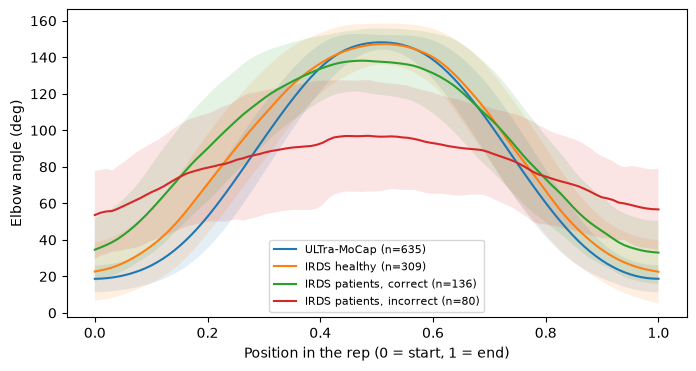

In [4]:
t = np.linspace(0, 1, N_STEPS)
fig, ax = plt.subplots(figsize=(8, 4))
for label, curves in (("ULTra-MoCap", ultra["angle"]),
                      ("IRDS healthy", irds["angle"][healthy]),
                      ("IRDS patients, correct", irds["angle"][patients & ~irds["incorrect"]]),
                      ("IRDS patients, incorrect", irds["angle"][patients & irds["incorrect"]])):
    m, s = curves.mean(0), curves.std(0)
    ax.plot(t, m, label=f"{label} (n={len(curves)})")
    ax.fill_between(t, m - s, m + s, alpha=0.12)
ax.set_xlabel("Position in the rep (0 = start, 1 = end)")
ax.set_ylabel("Elbow angle (deg)")
ax.legend(fontsize=8)
plt.show()

## 2. Splits and the two training mixes

Two mixes are compared. Each is trained with and without "how long the rep took" as an extra input
(a speed change is invisible once every rep is resampled to 100 steps).

In [5]:
def pick(angle, duration, mask):
    return angle[mask], duration[mask]


irds_stop = np.isin(irds["subject"], IRDS_STOP_SUBJECTS)
ultra_tr = np.isin(ultra["subject"], ULTRA_TRAIN_SUBJECTS)
ultra_st = np.isin(ultra["subject"], ULTRA_STOP_SUBJECTS)
parts = {
    "ultra_train": pick(ultra["angle"], ultra["duration"], ultra_tr),
    "ultra_stop": pick(ultra["angle"], ultra["duration"], ultra_st),
    "irds_train": pick(irds["angle"], irds["duration"], healthy & ~irds_stop),
    "irds_stop": pick(irds["angle"], irds["duration"], healthy & irds_stop),
}
MIXES = {"ULTra": (["ultra_train"], ["ultra_stop"]),
         "ULTra + healthy IRDS": (["ultra_train", "irds_train"], ["ultra_stop", "irds_stop"])}
for name, (tr, st) in MIXES.items():
    print(f"{name:<22} train {sum(len(parts[p][0]) for p in tr)} reps, early stop {sum(len(parts[p][0]) for p in st)} reps")

tune = np.isin(irds["subject"], TUNE_PATIENTS) & patients
test = np.isin(irds["subject"], TEST_PATIENTS) & patients
print(f"tuning patients: {(tune & ~irds['incorrect']).sum()} correct / {(tune & irds['incorrect']).sum()} incorrect reps")
print(f"test patients:   {(test & ~irds['incorrect']).sum()} correct / {(test & irds['incorrect']).sum()} incorrect reps")

ULTra                  train 524 reps, early stop 111 reps
ULTra + healthy IRDS   train 785 reps, early stop 159 reps
tuning patients: 63 correct / 43 incorrect reps
test patients:   73 correct / 37 incorrect reps


## 3. Model and training

In [7]:
class ConvAutoencoder(nn.Module):
    """(batch, channels, 100 steps) -> code of LATENT numbers -> (batch, channels, 100). Same layout as elbow_coach.py expects."""

    def __init__(self, n_channels, latent=LATENT):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(n_channels, 32, 5, stride=2, padding=2), nn.ReLU(),   # 100 -> 50
            nn.Conv1d(32, 64, 5, stride=2, padding=2), nn.ReLU(),           # 50 -> 25
            nn.Conv1d(64, 64, 5, stride=2, padding=2), nn.ReLU(),           # 25 -> 13
            nn.Flatten(), nn.Linear(64 * 13, latent))
        self.decoder_input = nn.Linear(latent, 64 * 13)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 64, 5, stride=2, padding=2), nn.ReLU(),                      # 13 -> 25
            nn.ConvTranspose1d(64, 32, 5, stride=2, padding=2, output_padding=1), nn.ReLU(),    # 25 -> 50
            nn.ConvTranspose1d(32, n_channels, 5, stride=2, padding=2, output_padding=1))        # 50 -> 100

    def forward(self, x):
        return self.decoder(self.decoder_input(self.encoder(x)).view(-1, 64, 13))


class Normaliser:
    """Per-channel mean 0 / std 1, fitted on training data only."""

    def fit(self, x):
        self.mean = x.mean(axis=(0, 1), keepdims=True)
        self.std = x.std(axis=(0, 1), keepdims=True) + 1e-6
        return self

    def __call__(self, x):
        return ((x - self.mean) / self.std).astype(np.float32)


def make_input(angle, duration, with_duration):
    """(reps, 100, channels): the angle curve, optionally + log(duration) repeated on every step."""
    x = angle[:, :, None].astype(np.float32)
    if with_duration:
        x = np.concatenate([x, np.log(duration.astype(float))[:, None, None] * np.ones((1, x.shape[1], 1))], axis=2)
    return x.astype(np.float32)


def to_tensor(x):
    return torch.from_numpy(x).permute(0, 2, 1)             # (reps, steps, channels) -> (reps, channels, steps)


def reconstruction_error(model, x):
    """Mean squared rebuild error per rep (on normalised data): the anomaly score."""
    model.eval()
    with torch.no_grad():
        t = to_tensor(x)
        return ((model(t) - t) ** 2).mean(dim=(1, 2)).numpy()


def rebuild_degrees(model, norm, x):
    """The rebuilt angle curve in degrees (channel 0) - what the rep 'should' have looked like."""
    model.eval()
    with torch.no_grad():
        out = model(to_tensor(norm(x))).permute(0, 2, 1).numpy()
    return out[:, :, 0] * norm.std[0, 0, 0] + norm.mean[0, 0, 0]


def fit(x_train, x_stop, seed):
    """Train on correct reps; keep the epoch with the lowest error on the early-stop reps."""
    torch.manual_seed(seed)
    model = ConvAutoencoder(n_channels=x_train.shape[2])
    opt = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    data = to_tensor(x_train)
    best, best_state, waited = np.inf, None, 0
    for epoch in range(1, EPOCHS + 1):
        model.train()
        for idx in torch.randperm(len(data)).split(BATCH_SIZE):
            batch = data[idx]
            loss = ((model(batch + NOISE * torch.randn_like(batch)) - batch) ** 2).mean()   # noise: a denoising autoencoder
            opt.zero_grad(); loss.backward(); opt.step()
        err = reconstruction_error(model, x_stop).mean()
        if err < best:
            best, best_state, waited = err, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            waited += 1
            if waited >= PATIENCE:
                break
    model.load_state_dict(best_state)
    return model


def best_threshold(err, incorrect):
    """Threshold with the best 'incorrect caught minus correct wrongly flagged' (Youden's J)."""
    fpr, tpr, thr = roc_curve(incorrect, err)
    return float(thr[np.argmax(tpr - fpr)])

## 4. Train every candidate (2 mixes x 2 inputs x 3 seeds)

Takes a few minutes on a CPU. The score here is how well the reconstruction error separates correct from incorrect
reps of the patients (AUC: 1.0 perfect, 0.5 guessing). The model is chosen on the **tuning** patients only.

In [8]:
def cat(names, with_duration):
    return np.concatenate([make_input(*parts[n], with_duration) for n in names])


runs = {}
for name, (tr, st) in MIXES.items():
    for with_duration in (False, True):
        norm = Normaliser().fit(cat(tr, with_duration))
        for seed in SEEDS:
            model = fit(norm(cat(tr, with_duration)), norm(cat(st, with_duration)), seed)
            err = reconstruction_error(model, norm(make_input(irds["angle"], irds["duration"], with_duration)))
            runs.setdefault((name, with_duration), []).append((model, norm, err))      # err = score of every IRDS rep
        auc = lambda m: [roc_auc_score(irds["incorrect"][m], r[2][m]) for r in runs[(name, with_duration)]]
        print(f"{name:<22}{'shape+duration' if with_duration else 'shape only':<16}"
              f"tuning AUC {np.mean(auc(tune)):.3f}   test AUC {np.mean(auc(test)):.3f} +- {np.std(auc(test)):.3f}")

ULTra                 shape only      tuning AUC 0.904   test AUC 0.823 +- 0.008
ULTra                 shape+duration  tuning AUC 0.937   test AUC 0.807 +- 0.016
ULTra + healthy IRDS  shape only      tuning AUC 0.870   test AUC 0.789 +- 0.019
ULTra + healthy IRDS  shape+duration  tuning AUC 0.884   test AUC 0.743 +- 0.011


## 5. Pick the model, set the thresholds and the tolerance band

- **balanced threshold**: tuned on the incorrect reps of the tuning patients (catches more, more false alarms).
- **gentle threshold**: the 95th percentile of healthy *Kinect* reps' errors. Needs no incorrect reps and no patients.
- **tolerance band**: how far (degrees) a healthy rep may stray from its rebuilt version at each step. It draws the green band in the warning picture.

The healthy reference must be the same kind of sensor the model will be used on: mocap errors are much lower than
Kinect errors, and a mocap-based threshold flagged 86% of correct patient reps. For the armband, use `recalibrate` (section 8).

In [10]:
def calibrate(model, norm, with_duration, ref_angle, ref_duration):
    """Gentle threshold and tolerance band from reps known to be correct (the reference reps)."""
    x = make_input(ref_angle, ref_duration, with_duration)
    gentle = float(np.percentile(reconstruction_error(model, norm(x)), GENTLE_PERCENTILE))
    deviation = np.abs(ref_angle - rebuild_degrees(model, norm, x))
    tol = np.maximum(np.percentile(deviation, TOLERANCE_PERCENTILE, axis=0), TOLERANCE_FLOOR_DEG)
    tol = np.convolve(np.pad(tol, 3, mode="edge"), np.ones(7) / 7, mode="valid")       # smooth along the rep
    return gentle, tol


best = max(runs, key=lambda k: np.mean([roc_auc_score(irds["incorrect"][tune], r[2][tune]) for r in runs[k]]))
mix, with_duration = best
model, norm, err = runs[best][0]                      # seed 0
train_names = MIXES[mix][0]
print(f"chosen on tuning patients: {mix}, {'shape + duration' if with_duration else 'shape only'}")

# reference reps = healthy IRDS reps the model did not train on
reference = healthy & irds_stop if "irds_train" in train_names else healthy
gentle, tolerance = calibrate(model, norm, with_duration, irds["angle"][reference], irds["duration"][reference])
balanced = best_threshold(err[tune], irds["incorrect"][tune])
train_durations = np.concatenate([parts[n][1] for n in train_names])
duration_range = (float(np.percentile(train_durations, 2)), float(np.percentile(train_durations, 98)))
print(f"balanced threshold {balanced:.4f}   gentle threshold {gentle:.4f}   "
      f"tolerance {tolerance.min():.0f}-{tolerance.max():.0f} deg   healthy rep length {duration_range[0]:.2f}-{duration_range[1]:.2f} s")

chosen on tuning patients: ULTra, shape + duration
balanced threshold 0.0383   gentle threshold 0.0575   tolerance 14-21 deg   healthy rep length 0.76-4.19 s


## 6. Final result on the 7 test patients (used once)

TEST patients [201, 205, 212, 213, 215, 216, 217]: 73 correct, 37 incorrect reps
AUC 0.787  (saved model, seed 0)

mode       threshold   correct wrongly warned  incorrect caught  macro F1  wheelchair false alarms
gentle        0.0575                    21.9%             64.9%     0.710                    17.1%
balanced      0.0383                    42.5%             75.7%     0.630                    51.4%

macro F1 = average of the F1 of the correct class and the F1 of the incorrect class (1.0 perfect, 0.5 or less = poor)


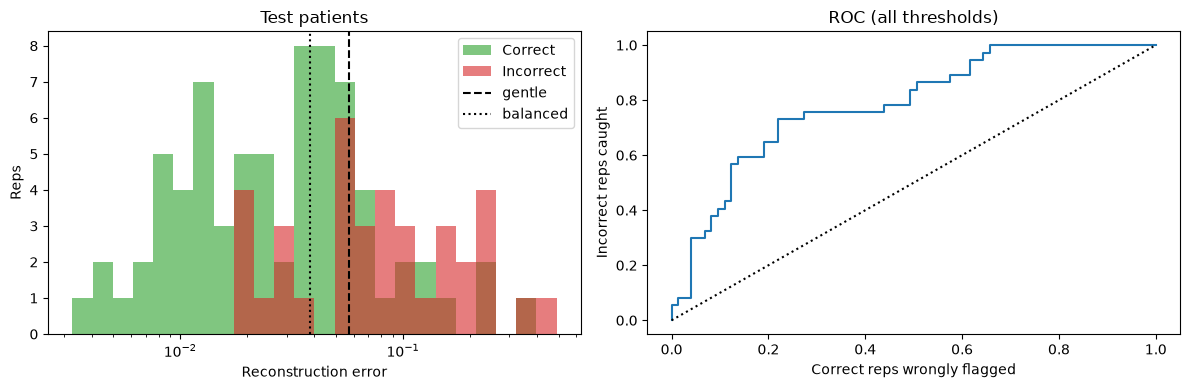

In [11]:
inc, pos = irds["incorrect"], irds["position"]
print(f"TEST patients {TEST_PATIENTS}: {(test & ~inc).sum()} correct, {(test & inc).sum()} incorrect reps")
print(f"AUC {roc_auc_score(inc[test], err[test]):.3f}  (saved model, seed 0)\n")
print(f"{'mode':<10}{'threshold':>10}{'correct wrongly warned':>25}{'incorrect caught':>18}{'macro F1':>10}{'wheelchair false alarms':>25}")
for label, thr in (("gentle", gentle), ("balanced", balanced)):
    flagged = err > thr
    wheel = test & ~inc & (pos == "wheelchair")
    print(f"{label:<10}{thr:>10.4f}{flagged[test & ~inc].mean():>25.1%}{flagged[test & inc].mean():>18.1%}{f1_score(inc[test], flagged[test], average='macro'):>10.3f}{flagged[wheel].mean():>25.1%}")

print()
print("macro F1 = average of the F1 of the correct class and the F1 of the incorrect class (1.0 perfect, 0.5 or less = poor)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(err[test & ~inc], bins=np.logspace(np.log10(err[test].min()), np.log10(err[test].max()), 25), alpha=0.6, color="tab:green", label="Correct")
axes[0].hist(err[test & inc], bins=np.logspace(np.log10(err[test].min()), np.log10(err[test].max()), 25), alpha=0.6, color="tab:red", label="Incorrect")
axes[0].axvline(gentle, color="black", linestyle="--", label="gentle")
axes[0].axvline(balanced, color="black", linestyle=":", label="balanced")
axes[0].set_xscale("log"); axes[0].set_xlabel("Reconstruction error"); axes[0].set_ylabel("Reps"); axes[0].set_title("Test patients"); axes[0].legend()
fpr, tpr, _ = roc_curve(inc[test], err[test])
axes[1].plot(fpr, tpr); axes[1].plot([0, 1], [0, 1], "k:")
axes[1].set_xlabel("Correct reps wrongly flagged"); axes[1].set_ylabel("Incorrect reps caught"); axes[1].set_title("ROC (all thresholds)")
plt.tight_layout(); plt.show()

## 7. Save and check it loads in the live coach

In [12]:
checkpoint = {"model_state": model.state_dict(), "mean": norm.mean, "std": norm.std, "with_duration": with_duration,
              "latent": LATENT, "threshold_balanced": balanced, "threshold_gentle": gentle, "tolerance": tolerance,
              "healthy_duration_range": duration_range}
torch.save(checkpoint, OUTPUT)

print(f"saved {OUTPUT}")
try:
    from elbow_coach import ElbowCoach      # same file the app side uses
except ImportError:
    ElbowCoach = None
    print("skipped the live-coach check: elbow_coach.py, arm_features.py and train_autoencoder.py are not in this folder")

if ElbowCoach is not None:
    coach = ElbowCoach(OUTPUT, mode="gentle")
    flagged_reps = np.flatnonzero(test & (err > gentle))[:3]          # a few warned reps and a few fine ones
    fine_reps = np.flatnonzero(test & (err <= gentle))[:2]
    for i in list(flagged_reps) + list(fine_reps):
        a, d = irds["angle"][i], irds["duration"][i]
        rep = coach.check_rep(a, fs=len(a) / d)
        assert np.isclose(rep["score"], err[i], rtol=1e-3), "coach and notebook disagree"
        print(f"patient {irds['subject'][i]} {'incorrect' if inc[i] else 'correct':<9} ok={rep['ok']!s:<5} "
              f"{[m['text'] for m in rep['messages'][:2]]}")
    print("the live coach reproduces the notebook scores")

try:                                         # in Google Colab, download the model to your computer
    from google.colab import files
    files.download(OUTPUT)
except ImportError:
    pass

saved elbow_final.pt
patient 201 incorrect ok=False ['Bend your elbow further', 'Start with your arm relaxed and straight']
patient 201 correct   ok=False ['Bend your elbow further']
patient 201 correct   ok=False ['Bend your elbow further', 'Straighten your arm fully at the end']
patient 201 incorrect ok=True  []
patient 201 incorrect ok=True  []
the live coach reproduces the notebook scores


## 8. Recalibrate for the armband

The thresholds and the green band depend on the sensor's noise. The model itself (what a healthy rep looks like) can
stay, but for the armband set the gentle threshold and the band from **your own correct reps**.

1. Calibrate the band (`z`, arm hanging relaxed).
2. Record 15-20 reps you know are done correctly, and cut each one into its own array of elbow angles (the live coach's
   rep finder does this; or use `coach.push` on the recording and keep `rep["angle"]`/`rep["duration_s"]`).
3. Call `recalibrate` with them.

Below it is tried with 20 healthy IRDS reps standing in for band reps (saved to a temporary file).

In [13]:
def curve_from_raw(angle, fs):
    """One rep recorded at fs Hz -> (100-step curve, duration in seconds)."""
    angle = np.asarray(angle, float)
    return np.interp(np.linspace(0, 1, N_STEPS), np.linspace(0, 1, len(angle)), angle), len(angle) / fs


def recalibrate(path_in, path_out, reps):
    """reps: list of (angle_array_in_degrees, sample_rate_hz) known to be correct. Keeps the model, resets thresholds and band."""
    ck = torch.load(path_in, weights_only=False)
    m = ConvAutoencoder(n_channels=2 if ck["with_duration"] else 1, latent=ck["latent"])
    m.load_state_dict(ck["model_state"])
    n = Normaliser(); n.mean, n.std = ck["mean"], ck["std"]
    curves, durations = zip(*[curve_from_raw(a, fs) for a, fs in reps])
    ck["threshold_gentle"], ck["tolerance"] = calibrate(m, n, ck["with_duration"], np.array(curves), np.array(durations))
    ck["threshold_balanced"] = ck["threshold_gentle"]          # no incorrect band reps yet, so no tuned 'balanced' value
    torch.save(ck, path_out)
    return ck["threshold_gentle"], ck["tolerance"]


stand_in = [(irds["angle"][i], len(irds["angle"][i]) / irds["duration"][i]) for i in np.flatnonzero(healthy)[:20]]
demo_path = os.path.join(tempfile.gettempdir(), "elbow_demo_calibrated.pt")
thr, band = recalibrate(OUTPUT, demo_path, stand_in)
print(f"recalibrated gentle threshold {thr:.4f} (was {gentle:.4f}), band {band.min():.0f}-{band.max():.0f} deg -> {demo_path}")
# For the band:  recalibrate("elbow_final.pt", "elbow_band.pt", band_reps)   then   ElbowCoach("elbow_band.pt")

recalibrated gentle threshold 0.0653 (was 0.0575), band 9-34 deg -> C:\Users\EHSANC~1\AppData\Local\Temp\elbow_demo_calibrated.pt


## Known limits
- Test result is 110 reps from 7 patients: expect a few points of error either way.
- Gentle mode (macro F1 0.71) warns about 22% of correct patient reps and catches about 65% of incorrect ones; balanced (macro F1 0.63) catches more but warns far more, especially on wheelchair users.
- Warning messages are rules on top of the rebuilt curve, not clinical advice.
- EMG is not used (IRDS has none).
- Not yet tested on armband recordings.